In [ ]:
# Load the CSV file

In [20]:
import pandas as pd
import numpy as np


df = pd.read_csv('customer churning.csv - Churn_Modelling.csv')

In [ ]:
# look at the first few rows

In [2]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,$0.00,1,1,1,"$101,348.88",1
1,2,15647311,Hill,608,Spain,Female,41,1,"$83,807.86",1,0,1,"$112,542.58",0
2,3,15619304,Onio,502,France,Female,42,8,"$159,660.80",3,1,0,"$113,931.57",1
3,4,15701354,Boni,699,France,Female,39,1,$0.00,2,0,0,"$93,826.63",0
4,5,15737888,Mitchell,850,Spain,Female,43,2,"$125,510.82",1,1,1,"$79,084.10",0


In [ ]:
# Checking the size of the dataset

In [4]:
df.shape


(10000, 14)

In [ ]:
# Checking the data types

In [5]:
df.dtypes

RowNumber          int64
CustomerId         int64
Surname              str
CreditScore        int64
Geography            str
Gender               str
Age                int64
Tenure             int64
Balance              str
NumOfProducts      int64
HasCrCard          int64
IsActiveMember     int64
EstimatedSalary      str
Exited             int64
dtype: object

In [ ]:
# Checking for missing values and duplicates

In [9]:
duplicates = df.duplicated().sum()
missing_data = df.isnull().sum() 
missing_data, duplicates

(RowNumber          0
 CustomerId         0
 Surname            0
 CreditScore        0
 Geography          0
 Gender             0
 Age                0
 Tenure             0
 Balance            0
 NumOfProducts      0
 HasCrCard          0
 IsActiveMember     0
 EstimatedSalary    0
 Exited             0
 dtype: int64,
 np.int64(0))

In [ ]:
# Checking unique customer IDs to ensure no duplicates

In [11]:
unique_customers = df['CustomerId'].nunique()

unique_customers, df[['CustomerId', 'Surname']].head(3)

(10000,
    CustomerId   Surname
 0    15634602  Hargrave
 1    15647311      Hill
 2    15619304      Onio)

In [ ]:
# Geting summary statistics

In [12]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,1.530200,0.70550,0.515100,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,0.581654,0.45584,0.499797,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,1.000000,0.00000,0.000000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,1.000000,0.00000,0.000000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,1.000000,1.00000,1.000000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,2.000000,1.00000,1.000000,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,4.000000,1.00000,1.000000,1.000000


In [ ]:
# Checking overall customer churn numbers and percentages

In [13]:
churn_counts = df['Exited'].value_counts()
churn_percentage = df['Exited'].value_counts(normalize=True) * 100

pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_percentage.round(2)})

,Count,Percentage (%)
Exited,,
0,7963,79.63
1,2037,20.37


In [ ]:
# Comparing churn across different countries

In [14]:
pd.crosstab(df['Geography'], df['Exited'])

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


In [ ]:
# Checking churn by gender and active membership status

In [16]:
df.groupby(['Gender',        'IsActiveMember'])['Exited'].mean().mul(100).round(2)

Gender  IsActiveMember
Female  0                 32.09
        1                 18.13
Male    0                 22.28
        1                 11.20
Name: Exited, dtype: float64

In [ ]:
# Checking min and max values for age, tenure, and credit score

In [17]:
df[['Age', 'Tenure', 'CreditScore']].agg(['min', 'max', 'mean']).round(1)

,Age,Tenure,CreditScore
min,18.0,0.0,350.0
max,92.0,10.0,850.0
mean,38.9,5.0,650.5


In [ ]:
# Visualize churn distribution

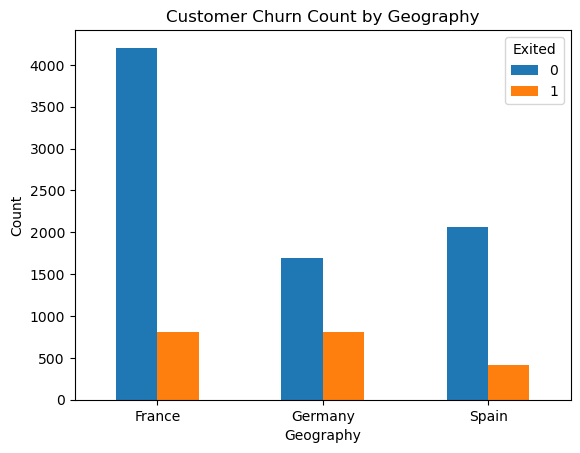

In [21]:
import matplotlib.pyplot as plt

pd.crosstab(df['Geography'], df['Exited']).plot(kind='bar', rot=0)
plt.title('Customer Churn Count by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

In [ ]:
# Export the cleaned dataset to a new CSV file

In [22]:
output_file = 'cleaned_churn_data.csv'
df.to_csv(output_file, index=False)

output_file

'cleaned_churn_data.csv'